## Location-Based Listing Recommendation

In this notebook, I use the final Random Forest model to recommend which listing types might perform best for a specific latitude and longitude.

The goal is to move from general model results into a more practical recommendation tool. Instead of only asking which features matter overall, I want to compare nearby listings and test different listing scenarios in the same location.

### Steps

- Load the final product modeling dataset.
- Load the saved Random Forest model and feature list.
- Choose a target latitude and longitude.
- Calculate each listing’s distance from that point.
- Filter nearby listings within a selected radius.
- Review the strongest local comps based on `reviews_per_month`.
- Build a few hypothetical listing scenarios for the same location.
- Use the model to predict demand for each scenario.
- Rank the scenarios and compare the model output to real local comps.

In [1]:
!pip install geopy

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from geopy.distance import geodesic

sns.set_theme(style='whitegrid', palette='Set2')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

set2_colors = sns.color_palette('Set2')

In [3]:
clean_path = '../data/processed/airbnb_clean.csv'
model_path = '../models/rf_location_recommendation_model.pkl'
features_path = '../models/rf_location_recommendation_features.pkl'

In [4]:
# final product feature dataset and saved recommendation model
df = pd.read_csv('../data/processed/airbnb_product_modeling.csv')

rf_model = joblib.load('../models/rf_location_recommendation_model.pkl')
rf_features = joblib.load('../models/rf_location_recommendation_features.pkl')

print('Recommendation dataset shape:', df.shape)
print('Model feature count:', len(rf_features))

# checking that the dataset has all features the model expects
missing_features = [col for col in rf_features if col not in df.columns]

print('Missing model features:', missing_features)

Recommendation dataset shape: (210525, 102)
Model feature count: 14
Missing model features: []


### Target location

I am starting with a test location in downtown San Diego. The same workflow can be reused with any latitude and longitude.

In [5]:
# Downtown San Diego
target_lat = 32.7157
target_lon = -117.1611
target_point = (target_lat, target_lon)

In [6]:
# calculating distance from the target location
df['distance_miles'] = df.apply(
    lambda row: geodesic(
        target_point,
        (row['latitude'], row['longitude'])).miles,
    axis=1)

In [7]:
# filtering nearby listings within the target radius
radius_miles = 3

local_comps = df[df['distance_miles'] <= radius_miles].copy()

print('Local comps shape:', local_comps.shape)

Local comps shape: (3167, 103)


In [8]:
local_comps[
    ['id', 'city', 'distance_miles', 'reviews_per_month',
     'room_type', 'accommodates', 'bedrooms', 'bathrooms',
     'price_clean', 'family_friendly_score', 'work_friendly_score',
     'amenity_strength_score', 'pricing_competitiveness_score']
].sort_values('reviews_per_month', ascending=False).head()

,id,city,distance_miles,reviews_per_month,room_type,accommodates,bedrooms,bathrooms,price_clean,family_friendly_score,work_friendly_score,amenity_strength_score,pricing_competitiveness_score
187878,808814447273523115,San Diego,0.084413,48.82,Entire home/apt,2,1.0,1.0,110.0,0,63,38,88.0
187877,808798275080007348,San Diego,0.221334,45.27,Entire home/apt,2,1.0,1.0,132.0,0,63,38,94.4
187959,808033005728294337,San Diego,0.059701,41.45,Entire home/apt,2,1.0,1.0,124.0,0,63,38,99.2
187738,787197038845726397,San Diego,0.264672,34.43,Private room,2,1.0,5.0,45.0,15,10,38,60.0
187881,808859465062374658,San Diego,0.180584,31.09,Entire home/apt,2,1.0,1.0,119.0,0,63,38,95.2


## Local Market Summary

Now that the nearby listings are filtered, I want to look at the local pattern.

This helps show what is already performing near the target location before creating new listing scenarios.

In [9]:
# checking which room types perform best nearby
local_room_summary = (
    local_comps
    .groupby('room_type')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_accommodates=('accommodates', 'mean'),
        avg_bedrooms=('bedrooms', 'mean'))
    .sort_values('avg_reviews_per_month', ascending=False)
    .round(2))

local_room_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bedrooms
room_type,,,,,,
Entire home/apt,2731,2.37,1.97,214.01,4.58,1.53
Private room,395,1.77,1.08,128.56,2.28,0.96
Shared room,39,1.74,1.25,58.87,2.36,1.00
Hotel room,2,0.84,0.84,205.50,4.00,1.00


Entire homes/apartments look like the strongest room type near downtown San Diego.

They have the highest average and median reviews per month, and they also have the largest listing count. That makes this pattern more useful than room types with very small sample sizes.

Private rooms and shared rooms have lower demand on average. Hotel rooms are hard to judge here because there are only 2 nearby listings.

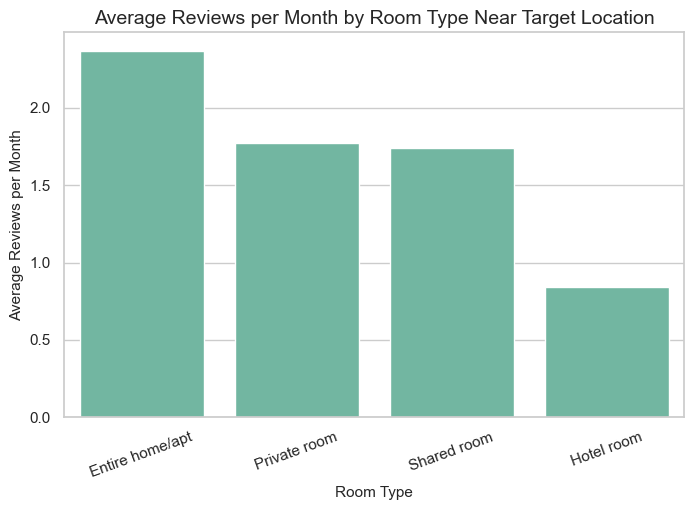

In [10]:
# comparing nearby demand by room type
plt.figure(figsize=(8, 5))

sns.barplot(
    data=local_room_summary.reset_index(),
    x='room_type',
    y='avg_reviews_per_month')

plt.title('Average Reviews per Month by Room Type Near Target Location')
plt.xlabel('Room Type')
plt.ylabel('Average Reviews per Month')
plt.xticks(rotation=20)
plt.show()

In [11]:
# checking which bedroom counts perform best nearby
local_bedroom_summary = (
    local_comps
    .groupby('bedrooms')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_accommodates=('accommodates', 'mean'))
    .sort_values('avg_reviews_per_month', ascending=False)
    .round(2))

local_bedroom_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates
bedrooms,,,,,
0.0,407,2.65,2.47,144.87,2.70
3.0,251,2.48,2.19,325.48,7.59
1.0,1525,2.31,1.71,144.49,2.93
2.0,839,2.11,1.71,226.67,5.25
4.0,98,1.91,1.75,511.92,10.17
5.0,29,1.64,1.28,750.62,12.72
8.0,5,0.86,0.69,570.00,16.00
6.0,11,0.84,0.37,895.00,14.18
7.0,2,0.45,0.45,1073.50,16.00


Studios and 3-bedroom listings look like the strongest bedroom groups near downtown San Diego.

Studios have the highest average and median reviews per month, and there are enough listings to make that pattern useful. This could mean smaller, efficient listings work well in this location.

3-bedroom listings also look strong. They have fewer listings than 1-bedrooms, but still enough to take seriously. This could mean larger group or family-friendly stays are also performing well nearby.

Larger listings with 5+ bedrooms seem less consistent here. They are more expensive, have smaller sample sizes, and show lower average demand.

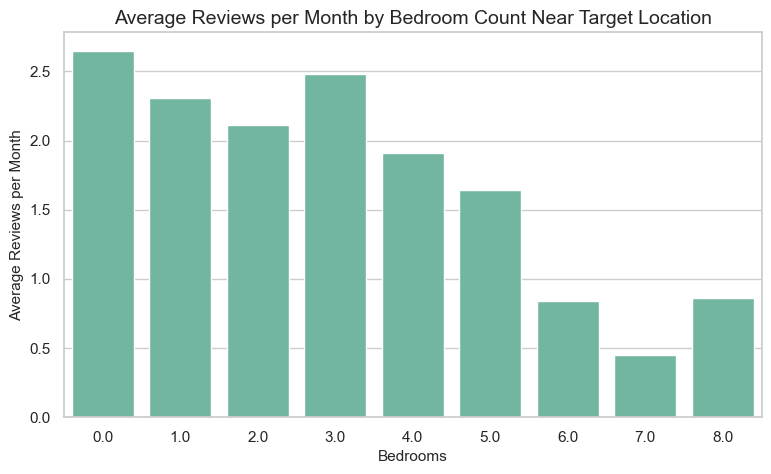

In [12]:
# comparing nearby demand by bedroom count
bedroom_plot = local_bedroom_summary.reset_index().sort_values('bedrooms')

plt.figure(figsize=(9, 5))

sns.barplot(
    data=bedroom_plot,
    x='bedrooms',
    y='avg_reviews_per_month')

plt.title('Average Reviews per Month by Bedroom Count Near Target Location')
plt.xlabel('Bedrooms')
plt.ylabel('Average Reviews per Month')
plt.show()

## Guest Capacity Summary

Next, I want to look at demand by guest capacity.

Bedroom count shows the listing size, but `accommodates` gives a better idea of who the listing is built for. This helps compare smaller stays, family-sized stays, and larger group stays near the same location.

In [13]:
# checking which guest capacity groups perform best nearby
local_capacity_summary = (
    local_comps
    .groupby('accommodates')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_bedrooms=('bedrooms', 'mean'),
        avg_bathrooms=('bathrooms', 'mean'))
    .sort_values('avg_reviews_per_month', ascending=False)
    .round(2))

local_capacity_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_bedrooms,avg_bathrooms
accommodates,,,,,,
12,36,2.56,1.96,504.28,3.86,2.62
6,398,2.56,2.28,246.75,2.03,1.57
2,976,2.46,1.85,127.11,0.75,1.18
10,61,2.46,2.20,449.28,3.26,2.35
8,162,2.42,2.14,312.75,2.66,1.78
7,66,2.41,2.23,299.59,2.44,1.70
4,788,2.24,1.88,185.88,1.28,1.21
9,33,2.23,2.19,402.67,3.42,2.35
3,255,2.11,1.29,158.04,0.87,1.04


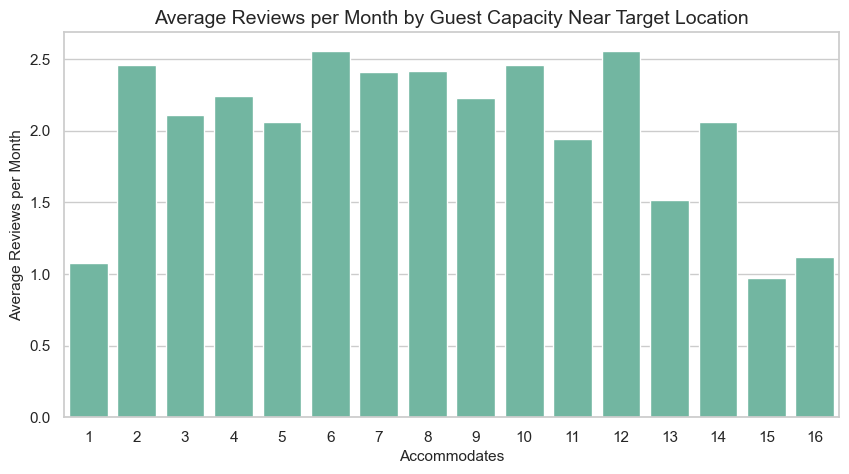

In [14]:
# comparing nearby demand by guest capacity
capacity_plot = local_capacity_summary.reset_index().sort_values('accommodates')

plt.figure(figsize=(10, 5))

sns.barplot(
    data=capacity_plot,
    x='accommodates',
    y='avg_reviews_per_month')

plt.title('Average Reviews per Month by Guest Capacity Near Target Location')
plt.xlabel('Accommodates')
plt.ylabel('Average Reviews per Month')
plt.show()

## Local Pricing Summary

Next, I want to look at pricing near the target location.

This helps show whether higher-demand listings are priced lower, higher, or more competitively compared to nearby listings. Pricing could be one reason certain listing types perform better than others.

In [15]:
# checking local pricing patterns
local_price_summary = local_comps[
    ['price_clean', 'pricing_competitiveness_score', 'reviews_per_month']
].describe().round(2)

local_price_summary

,price_clean,pricing_competitiveness_score,reviews_per_month
count,3167.00,3167.00,3167.00
mean,201.44,65.78,2.29
std,182.26,26.66,2.48
min,20.00,0.00,0.01
25%,111.00,52.00,0.60
50%,150.00,71.78,1.82
75%,220.50,86.45,3.34
max,2000.00,100.00,48.82


In [16]:
# grouping prices into ranges so the local pattern is easier to compare
local_comps['price_tier'] = pd.qcut(
    local_comps['price_clean'],
    q=4,
    labels=['low', 'mid-low', 'mid-high', 'high'])

local_price_tiers = (
    local_comps
    .groupby('price_tier', observed=True)
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_pricing_score=('pricing_competitiveness_score', 'mean'))
    .round(2))

local_price_tiers

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_pricing_score
price_tier,,,,,
low,796,2.38,1.99,85.51,70.09
mid-low,814,2.65,2.12,130.19,73.53
mid-high,765,2.30,1.77,181.15,69.86
high,792,1.82,1.32,410.78,49.54


The mid-low price tier looks strongest near the target location.

These listings have the highest average and median reviews per month, which could mean that guests in this area respond well to listings that feel like a good deal without being the cheapest option.

The high price tier has the lowest demand. This doesn't mean expensive listings cannot perform well, but it does suggest that more expensive listings may need stronger features, better positioning, or a more specific guest type to stay competitive.

## Local Product Feature Summary

Comparing demand across product feature scores helps show whether listings with stronger family, work, or amenity signals seem to perform better near the target location.

In [17]:
# checking how product feature scores relate to local demand
product_score_cols = [
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score',
    'pricing_competitiveness_score',
    'reviews_per_month']

local_comps[product_score_cols].corr()['reviews_per_month'].sort_values(ascending=False).round(3)

reviews_per_month                1.000
pricing_competitiveness_score    0.114
work_friendly_score              0.051
amenity_strength_score           0.036
family_friendly_score           -0.062
Name: reviews_per_month, dtype: float64

Family-friendly features aren't a strong demand driver near downtown San Diego and should not be the main positioning strategy for a listing here.

The family-friendly score has a negative correlation with reviews per month. This could mean downtown demand is more focused on short city stays, work trips, events, nightlife, or couples/small groups rather than families.

## Create Listing Scenarios

Each scenario keeps the latitude and longitude the same, but changes the listing type, price, size, and product scores. This makes it easier to compare which type of listing the model expects to perform best in the same area.

In [18]:
# creating scenarios so each listing type can be compared in the same location
scenario_data = [
    {
        'scenario': 'Budget studio',
        'price_clean': 125,
        'pricing_competitiveness_score': 75,
        'accommodates': 2,
        'bedrooms': 0,
        'beds': 1,
        'bathrooms': 1,
        'latitude': target_lat,
        'longitude': target_lon,
        'host_is_superhost': 1,
        'host_response_time_ord': 4,
        'instant_bookable': 1,
        'family_friendly_score': 0,
        'work_friendly_score': 3,
        'amenity_strength_score': 8},
    {
        'scenario': 'Standard 1-bedroom',
        'price_clean': 160,
        'pricing_competitiveness_score': 70,
        'accommodates': 3,
        'bedrooms': 1,
        'beds': 2,
        'bathrooms': 1,
        'latitude': target_lat,
        'longitude': target_lon,
        'host_is_superhost': 1,
        'host_response_time_ord': 4,
        'instant_bookable': 1,
        'family_friendly_score': 2,
        'work_friendly_score': 4,
        'amenity_strength_score': 10},
    {
        'scenario': 'Mid-priced 2-bedroom',
        'price_clean': 225,
        'pricing_competitiveness_score': 65,
        'accommodates': 5,
        'bedrooms': 2,
        'beds': 3,
        'bathrooms': 2,
        'latitude': target_lat,
        'longitude': target_lon,
        'host_is_superhost': 1,
        'host_response_time_ord': 4,
        'instant_bookable': 1,
        'family_friendly_score': 5,
        'work_friendly_score': 4,
        'amenity_strength_score': 12},
    {
        'scenario': 'Group-friendly 3-bedroom',
        'price_clean': 325,
        'pricing_competitiveness_score': 60,
        'accommodates': 8,
        'bedrooms': 3,
        'beds': 4,
        'bathrooms': 2,
        'latitude': target_lat,
        'longitude': target_lon,
        'host_is_superhost': 1,
        'host_response_time_ord': 4,
        'instant_bookable': 1,
        'family_friendly_score': 6,
        'work_friendly_score': 4,
        'amenity_strength_score': 14}
]

scenario_df = pd.DataFrame(scenario_data)

scenario_df

,scenario,price_clean,pricing_competitiveness_score,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,host_response_time_ord,instant_bookable,family_friendly_score,work_friendly_score,amenity_strength_score
0,Budget studio,125,75,2,0,1,1,32.7157,-117.1611,1,4,1,0,3,8
1,Standard 1-bedroom,160,70,3,1,2,1,32.7157,-117.1611,1,4,1,2,4,10
2,Mid-priced 2-bedroom,225,65,5,2,3,2,32.7157,-117.1611,1,4,1,5,4,12
3,Group-friendly 3-bedroom,325,60,8,3,4,2,32.7157,-117.1611,1,4,1,6,4,14


In [19]:
# checking that each scenario has the features the model needs
scenario_features = scenario_df[rf_features]

## Predict Scenario Demand

Using Random Forest to estimate demand for each downtown San Diego scenario.

The model predicts log-transformed reviews per month, so I convert the predictions back into normal reviews per month.

In [20]:
# predicting demand for each listing scenario
scenario_pred_log = rf_model.predict(scenario_df[rf_features])
scenario_pred = np.expm1(scenario_pred_log)

scenario_df['predicted_reviews_per_month'] = scenario_pred

scenario_results = (
    scenario_df
    .sort_values('predicted_reviews_per_month', ascending=False)
    .round(2))

scenario_results[
    ['scenario', 'predicted_reviews_per_month', 'price_clean',
     'pricing_competitiveness_score', 'accommodates', 'bedrooms',
     'bathrooms', 'family_friendly_score', 'work_friendly_score',
     'amenity_strength_score']]

,scenario,predicted_reviews_per_month,price_clean,pricing_competitiveness_score,accommodates,bedrooms,bathrooms,family_friendly_score,work_friendly_score,amenity_strength_score
0,Budget studio,1.84,125,75,2,0,1,0,3,8
2,Mid-priced 2-bedroom,1.53,225,65,5,2,2,5,4,12
1,Standard 1-bedroom,1.45,160,70,3,1,1,2,4,10
3,Group-friendly 3-bedroom,1.21,325,60,8,3,2,6,4,14


The budget studio has the highest predicted demand in this downtown San Diego test.

This fits with the local comps, where studios had strong average and median reviews per month. It also fits with the pricing summary, where lower and mid-low priced listings looked stronger than high-priced listings.

The 3-bedroom group-friendly scenario has the lowest predicted demand here. This does not mean 3-bedroom listings cannot work downtown, but this specific scenario may be too expensive or less aligned with the strongest local demand pattern.

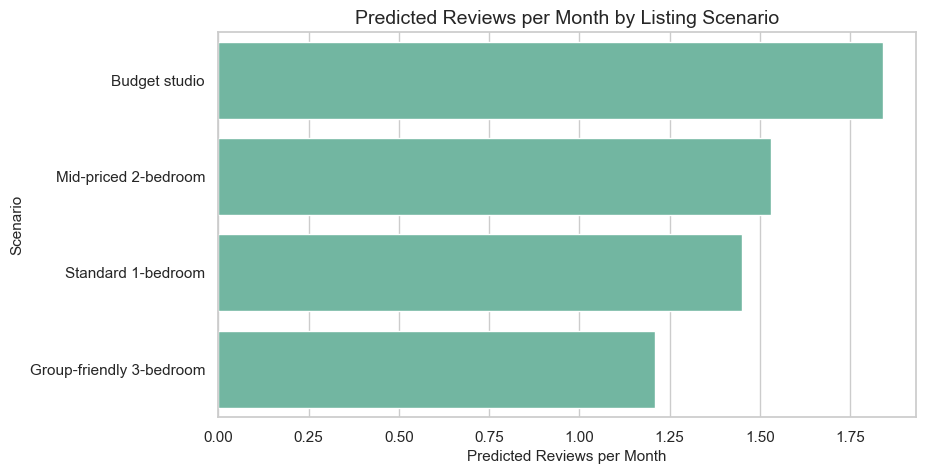

In [21]:
# comparing predicted demand across listing scenarios
plt.figure(figsize=(9, 5))

sns.barplot(
    data=scenario_results,
    x='predicted_reviews_per_month',
    y='scenario')

plt.title('Predicted Reviews per Month by Listing Scenario')
plt.xlabel('Predicted Reviews per Month')
plt.ylabel('Scenario')
plt.show()

## Select the Best Scenario

Now I want to pull out the highest-ranked scenario from the model results.

This makes the output easier to read and starts turning the model prediction into a clear recommendation.

In [22]:
# pulling the highest predicted scenario
best_scenario = scenario_results.iloc[0]

best_scenario

scenario                         Budget studio
price_clean                                125
pricing_competitiveness_score               75
accommodates                                 2
bedrooms                                     0
beds                                         1
bathrooms                                    1
latitude                                 32.72
longitude                              -117.16
host_is_superhost                            1
host_response_time_ord                       4
instant_bookable                             1
family_friendly_score                        0
work_friendly_score                          3
amenity_strength_score                       8
predicted_reviews_per_month               1.84
Name: 0, dtype: object

In [23]:
# creating a simple recommendation sentence from the best scenario
print(f'Best scenario: {best_scenario["scenario"]}')
print(f'Predicted reviews per month: {best_scenario["predicted_reviews_per_month"]:.2f}')
print(f'Price: ${best_scenario["price_clean"]:.0f}')
print(f'Accommodates: {best_scenario["accommodates"]:.0f}')
print(f'Bedrooms: {best_scenario["bedrooms"]:.0f}')
print(f'Bathrooms: {best_scenario["bathrooms"]:.0f}')

Best scenario: Budget studio
Predicted reviews per month: 1.84
Price: $125
Accommodates: 2
Bedrooms: 0
Bathrooms: 1


### Recommended amenities: 
- Strong WiFi
- Dedicated workspace or small desk setup
- Self check-in
- Air conditioning
- Kitchen or kitchenette
- Coffee maker
- Washer/dryer or laundry access
- Good lighting
- Comfortable queen bed
- Smart TV or streaming
- Extra towels and linens
- Luggage dropoff if possible
- Paid or clear parking info
- Walkability / downtown access highlighted in the listing

In [24]:
# filtering local studio listings to compare similar high-performing comps
studio_comps = local_comps[
    (local_comps['bedrooms'] == 0) &
    (local_comps['accommodates'] <= 2)].copy()

studio_comps.shape

(264, 104)

## Studio Amenity and Price Positioning

The model picked a budget studio as the strongest scenario near downtown San Diego.

Next, I want to look at similar studio comps to see what higher-priced studios have in common. This can help identify features or positioning choices that might support a higher ADR without changing the listing into a larger property.

In [25]:
# splitting studio comps into price tiers
studio_comps['studio_price_tier'] = pd.qcut(
    studio_comps['price_clean'],
    q=4,
    labels=['low', 'mid-low', 'mid-high', 'high'])

studio_price_summary = (
    studio_comps
    .groupby('studio_price_tier', observed=True)
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_work_score=('work_friendly_score', 'mean'),
        avg_family_score=('family_friendly_score', 'mean'),
        avg_amenity_score=('amenity_strength_score', 'mean'),
        avg_pricing_score=('pricing_competitiveness_score', 'mean'))
    .round(2))

studio_price_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_work_score,avg_family_score,avg_amenity_score,avg_pricing_score
studio_price_tier,,,,,,,,
low,68,2.57,2.48,77.85,62.22,38.09,72.10,66.84
mid-low,66,2.68,3.00,102.95,61.23,38.48,73.15,82.32
mid-high,64,3.12,3.42,123.06,63.00,44.53,74.47,95.71
high,66,2.57,2.36,184.68,60.33,50.83,72.48,62.15


For downtown studios, the mid-high price tier looks strongest.

These studios average about $123 per night and have the highest average and median reviews per month. This could mean the best opportunity is not the cheapest studio, but a well-priced studio that feels stronger than basic budget options.

The high price tier does not perform as well, even though those listings have the highest family-friendly score. This fits the earlier pattern that family positioning does not seem like the strongest downtown strategy.

The mid-high tier also has the highest amenity strength score and the strongest pricing competitiveness score. This could mean downtown studios can support a higher ADR when they still feel like a good value and have solid amenities.

## Reusable Function

Creating a resuable function that takes the lat, lon, and radius to predict the properties with the most demand.

In [26]:
def get_local_comps(df, target_lat, target_lon, radius_miles=3):
    target_point = (target_lat, target_lon)

    local_df = df.copy()

    local_df['distance_miles'] = local_df.apply(
        lambda row: geodesic(
            target_point,
            (row['latitude'], row['longitude'])).miles,
        axis=1)

    local_comps = local_df[local_df['distance_miles'] <= radius_miles].copy()

    return local_comps

In [27]:
# testing the local comps function with downtown San Diego
downtown_comps = get_local_comps(
    df=df,
    target_lat=32.7157,
    target_lon=-117.1611,
    radius_miles=3)

print('Downtown comps shape:', downtown_comps.shape)

Downtown comps shape: (3167, 103)


In [28]:
north_park_comps = get_local_comps(df, 32.7484, -117.1303, radius_miles=3)

In [29]:
bankers_hill_comps = get_local_comps(df, 32.7281, -117.1647, radius_miles=3)

## Build a Reusable Location Summary

The first function filters listings near a target location.

Next, I want a second function that summarizes the local comps. This makes it easier to compare different neighborhoods without repeating the same groupby code each time.

In [30]:
def summarize_location(local_comps):
    room_summary = (
        local_comps
        .groupby('room_type')
        .agg(
            listing_count=('id', 'count'),
            avg_reviews_per_month=('reviews_per_month', 'mean'),
            median_reviews_per_month=('reviews_per_month', 'median'),
            avg_price=('price_clean', 'mean'),
            avg_accommodates=('accommodates', 'mean'),
            avg_bedrooms=('bedrooms', 'mean'))
        .sort_values('avg_reviews_per_month', ascending=False)
        .round(2))

    bedroom_summary = (
        local_comps
        .groupby('bedrooms')
        .agg(
            listing_count=('id', 'count'),
            avg_reviews_per_month=('reviews_per_month', 'mean'),
            median_reviews_per_month=('reviews_per_month', 'median'),
            avg_price=('price_clean', 'mean'),
            avg_accommodates=('accommodates', 'mean'))
        .sort_values('avg_reviews_per_month', ascending=False)
        .round(2))

    capacity_summary = (
        local_comps
        .groupby('accommodates')
        .agg(
            listing_count=('id', 'count'),
            avg_reviews_per_month=('reviews_per_month', 'mean'),
            median_reviews_per_month=('reviews_per_month', 'median'),
            avg_price=('price_clean', 'mean'),
            avg_bedrooms=('bedrooms', 'mean'))
        .sort_values('avg_reviews_per_month', ascending=False)
        .round(2))

    return room_summary, bedroom_summary, capacity_summary

## Testing/checking functions

In [31]:
downtown_room_summary, downtown_bedroom_summary, downtown_capacity_summary = summarize_location(downtown_comps)

downtown_room_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bedrooms
room_type,,,,,,
Entire home/apt,2731,2.37,1.97,214.01,4.58,1.53
Private room,395,1.77,1.08,128.56,2.28,0.96
Shared room,39,1.74,1.25,58.87,2.36,1.00
Hotel room,2,0.84,0.84,205.50,4.00,1.00


In [32]:
downtown_bedroom_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates
bedrooms,,,,,
0.0,407,2.65,2.47,144.87,2.70
3.0,251,2.48,2.19,325.48,7.59
1.0,1525,2.31,1.71,144.49,2.93
2.0,839,2.11,1.71,226.67,5.25
4.0,98,1.91,1.75,511.92,10.17
5.0,29,1.64,1.28,750.62,12.72
8.0,5,0.86,0.69,570.00,16.00
6.0,11,0.84,0.37,895.00,14.18
7.0,2,0.45,0.45,1073.50,16.00


In [33]:
downtown_capacity_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_bedrooms
accommodates,,,,,
12,36,2.56,1.96,504.28,3.86
6,398,2.56,2.28,246.75,2.03
2,976,2.46,1.85,127.11,0.75
10,61,2.46,2.20,449.28,3.26
8,162,2.42,2.14,312.75,2.66
7,66,2.41,2.23,299.59,2.44
4,788,2.24,1.88,185.88,1.28
9,33,2.23,2.19,402.67,3.42
3,255,2.11,1.29,158.04,0.87


## Checking/testing functions on North Park, San Diego

In [34]:
north_park_room_summary, north_park_bedroom_summary, north_park_capacity_summary = summarize_location(north_park_comps)

north_park_room_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bedrooms
room_type,,,,,,
Entire home/apt,2955,2.46,2.08,201.28,4.46,1.54
Shared room,30,1.80,1.28,58.30,2.77,1.00
Private room,458,1.49,0.96,122.21,2.18,0.98
Hotel room,2,0.84,0.84,205.50,4.00,1.00


## Checking/testing functions on Bankers Hill, San Diego

In [35]:
bankers_hill_room_summary, bankers_hill_bedroom_summary, bankers_hill_capacity_summary = summarize_location(bankers_hill_comps)

bankers_hill_room_summary

,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bedrooms
room_type,,,,,,
Entire home/apt,2975,2.36,1.96,210.96,4.52,1.52
Shared room,39,1.74,1.25,58.87,2.36,1.00
Private room,448,1.68,1.04,126.54,2.28,0.99
Hotel room,2,0.84,0.84,205.50,4.00,1.00


## Amenity Recommendations

I want to be able to recommend basic amenities and price-driving amenities, to help hosts build more desirable listings. 

Must-have amenities are common in the strongest nearby listings. Bonus amenities are amenities that show up more often in high-performing listings than in the full local market.

In [36]:
# checking which amenity columns are available for recommendation
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

amenity_cols[:20], len(amenity_cols)

(['amenity_air_conditioning',
  'amenity_bathtub',
  'amenity_bbq_grill',
  'amenity_beach_access',
  'amenity_bed_linens',
  'amenity_blender',
  'amenity_carbon_monoxide_alarm',
  'amenity_cleaning_supplies',
  'amenity_coffee_maker',
  'amenity_cooking_basics',
  'amenity_dishwasher',
  'amenity_dryer',
  'amenity_essentials',
  'amenity_ev_charger',
  'amenity_fan',
  'amenity_fire_extinguisher',
  'amenity_fireplace',
  'amenity_first_aid_kit',
  'amenity_flexible_checkin',
  'amenity_game_console'],
 58)

In [37]:
# keeping only individual amenity columns, not the combined amenity score
amenity_cols = [
    col for col in df.columns 
    if col.startswith('amenity_') and col != 'amenity_strength_score']

# converting amenity columns to numeric so rates can be calculated
df[amenity_cols] = df[amenity_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

print('Amenity column count:', len(amenity_cols))
print(df[amenity_cols].dtypes.value_counts())

Amenity column count: 57
int64      56
float64     1
Name: count, dtype: int64


In [38]:
def get_amenity_recommendations(local_comps, amenity_cols, top_percent=.25):
    demand_cutoff = local_comps['reviews_per_month'].quantile(1 - top_percent)

    top_comps = local_comps[
        local_comps['reviews_per_month'] >= demand_cutoff].copy()

    amenity_summary = pd.DataFrame({
        'overall_rate': local_comps[amenity_cols].mean(),
        'top_comp_rate': top_comps[amenity_cols].mean()})

    amenity_summary['rate_lift'] = (
        amenity_summary['top_comp_rate'] - amenity_summary['overall_rate'])

    amenity_summary = (
        amenity_summary
        .reset_index()
        .rename(columns={'index': 'amenity'})
        .sort_values(['top_comp_rate', 'rate_lift'], ascending=False))

    amenity_summary['amenity'] = (
        amenity_summary['amenity']
        .str.replace('amenity_', '', regex=False)
        .str.replace('_', ' '))

    return amenity_summary.round(3)

In [39]:
# recreating local comps after cleaning amenity columns
downtown_comps = get_local_comps(
    df=df,
    target_lat=32.7157,
    target_lon=-117.1611,
    radius_miles=3)

north_park_comps = get_local_comps(
    df=df,
    target_lat=32.7484,
    target_lon=-117.1303,
    radius_miles=3)

bankers_hill_comps = get_local_comps(
    df=df,
    target_lat=32.7281,
    target_lon=-117.1647,
    radius_miles=3)

In [40]:
# checking amenity patterns in top-performing downtown listings
downtown_amenities = get_amenity_recommendations(
    local_comps=downtown_comps,
    amenity_cols=amenity_cols,
    top_percent=.25)

downtown_amenities.tail(15)

,amenity,overall_rate,top_comp_rate,rate_lift
20,gym,0.208,0.094,-0.114
16,fireplace,0.118,0.090,-0.028
51,view other,0.074,0.075,0.001
25,hot tub,0.162,0.075,-0.087
38,pool,0.133,0.074,-0.059
52,view water,0.084,0.063,-0.021
44,sound system,0.058,0.053,-0.006
3,beach access,0.050,0.041,-0.009
13,ev charger,0.041,0.033,-0.008
24,host services,0.072,0.031,-0.040


## Create Amenity Recommendation Lists

The full amenity table is useful, but it is too detailed for a final recommendation.

Next, I want to separate amenities into clearer groups:
- must-have amenities
- bonus amenities
- amenities that do not look like a strong fit for this location

In [41]:
# pulling amenities that stand out more in top-performing downtown comps
downtown_bonus_amenities = (
    downtown_amenities[
        (downtown_amenities['top_comp_rate'] >= .25) &
        (downtown_amenities['rate_lift'] >= .05)]
    .sort_values('rate_lift', ascending=False))

downtown_bonus_amenities

,amenity,overall_rate,top_comp_rate,rate_lift
41,self checkin,0.717,0.856,0.139
39,private entrance,0.587,0.715,0.127
4,bed linens,0.752,0.870,0.118
31,microwave,0.811,0.896,0.085
18,flexible checkin,0.298,0.378,0.080
8,coffee maker,0.849,0.927,0.079
47,toiletries,0.851,0.920,0.069
26,hot water,0.849,0.919,0.069
27,iron,0.828,0.891,0.064
28,kids amenities,0.388,0.452,0.064


## Studio ADR Amenity Drivers

The first amenity table mostly showed basic amenities in high-demand listings.

Next, I want to look at higher-priced studio comps instead. This is a better way to see which amenities might support a higher ADR for a downtown studio.

In [42]:
# checking which amenities are more common in higher-priced studio comps
def get_price_driver_amenities(comps, amenity_cols, top_percent=.25):
    price_cutoff = comps['price_clean'].quantile(1 - top_percent)

    high_price_comps = comps[
        comps['price_clean'] >= price_cutoff].copy()

    amenity_summary = pd.DataFrame({
        'overall_rate': comps[amenity_cols].mean(),
        'high_price_rate': high_price_comps[amenity_cols].mean()})

    amenity_summary['rate_lift'] = (
        amenity_summary['high_price_rate'] - amenity_summary['overall_rate'])

    amenity_summary = (
        amenity_summary
        .reset_index()
        .rename(columns={'index': 'amenity'}))

    amenity_summary['amenity'] = (
        amenity_summary['amenity']
        .str.replace('amenity_', '', regex=False)
        .str.replace('_', ' '))

    return amenity_summary.round(3)

In [43]:
# recreating studio comps after cleaning amenity columns
studio_comps = downtown_comps[
    (downtown_comps['bedrooms'] == 0) &
    (downtown_comps['accommodates'] <= 2)].copy()

# making sure studio amenity columns are numeric
studio_comps[amenity_cols] = (
    studio_comps[amenity_cols]
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0))

studio_comps[amenity_cols].dtypes.value_counts()

int64      56
float64     1
Name: count, dtype: int64

In [44]:
# checking possible ADR amenity drivers for downtown studios
downtown_studio_price_drivers = get_price_driver_amenities(
    comps=studio_comps,
    amenity_cols=amenity_cols,
    top_percent=.25)

downtown_studio_price_drivers.sort_values('rate_lift', ascending=False).head(20)

,amenity,overall_rate,high_price_rate,rate_lift
29,kitchen,0.629,0.924,0.295
34,oven,0.345,0.606,0.261
45,stove,0.405,0.652,0.246
10,dishwasher,0.167,0.379,0.212
9,cooking basics,0.712,0.864,0.152
30,long term stays,0.299,0.424,0.125
37,patio balcony,0.417,0.530,0.114
35,parking free,0.598,0.712,0.114
5,blender,0.080,0.167,0.087
49,view city,0.110,0.197,0.087


## Classify Standard vs Premium Amenities

The price driver table gives a better view of amenities that might support a higher ADR.

Next, I want to separate amenities into standard amenities and premium amenities. Standard amenities are common in most studio comps. Premium amenities are less common overall, but show up more often in higher-priced studios.

In [45]:
# classifying studio amenities by how common they are and how much they show up in higher-priced comps
studio_amenity_types = downtown_studio_price_drivers.copy()

def classify_amenity(row):
    if row['overall_rate'] >= .70:
        return 'standard'
    elif row['overall_rate'] < .70 and row['high_price_rate'] >= .20 and row['rate_lift'] >= .07:
        return 'premium'
    elif row['overall_rate'] < .20 and row['rate_lift'] >= .05:
        return 'possible niche premium'
    else:
        return 'lower signal'

studio_amenity_types['amenity_type'] = studio_amenity_types.apply(classify_amenity, axis=1)

studio_amenity_types.sort_values(['amenity_type', 'rate_lift'], ascending=[True, False]).head(30)

,amenity,overall_rate,high_price_rate,rate_lift,amenity_type
36,parking paid,0.212,0.273,0.061,lower signal
46,toaster,0.201,0.258,0.057,lower signal
3,beach access,0.027,0.076,0.049,lower signal
38,pool,0.030,0.076,0.045,lower signal
1,bathtub,0.216,0.258,0.042,lower signal
16,fireplace,0.027,0.061,0.034,lower signal
44,sound system,0.045,0.076,0.030,lower signal
52,view water,0.034,0.061,0.027,lower signal
14,fan,0.197,0.212,0.015,lower signal
19,game console,0.004,0.015,0.011,lower signal


In [46]:
# pulling standard amenities for downtown studios
standard_studio_amenities = (
    studio_amenity_types[
        studio_amenity_types['amenity_type'] == 'standard']
    .sort_values('overall_rate', ascending=False))

standard_studio_amenities

,amenity,overall_rate,high_price_rate,rate_lift,amenity_type
54,wifi,0.996,0.985,-0.011,standard
43,smoke alarm,0.977,0.985,0.008,standard
48,tv,0.939,0.939,0.000,standard
12,essentials,0.936,0.909,-0.027,standard
6,carbon monoxide alarm,0.924,0.864,-0.061,standard
40,refrigerator,0.917,0.894,-0.023,standard
21,hair dryer,0.913,0.909,-0.004,standard
23,heating,0.890,0.848,-0.042,standard
8,coffee maker,0.883,0.848,-0.034,standard
22,hangers,0.883,0.833,-0.049,standard


In [47]:
# pulling premium amenities that may support higher ADR
premium_studio_amenities = (
    studio_amenity_types[
        studio_amenity_types['amenity_type'].isin(['premium', 'possible niche premium'])]
    .sort_values('rate_lift', ascending=False))

premium_studio_amenities

,amenity,overall_rate,high_price_rate,rate_lift,amenity_type
29,kitchen,0.629,0.924,0.295,premium
34,oven,0.345,0.606,0.261,premium
45,stove,0.405,0.652,0.246,premium
10,dishwasher,0.167,0.379,0.212,premium
30,long term stays,0.299,0.424,0.125,premium
37,patio balcony,0.417,0.530,0.114,premium
35,parking free,0.598,0.712,0.114,premium
49,view city,0.110,0.197,0.087,possible niche premium
5,blender,0.080,0.167,0.087,possible niche premium
25,hot tub,0.102,0.182,0.080,possible niche premium


Full kitchen features seem to support higher ADR for downtown studios.

This does not mean a kitchen is luxury, so the name "Premium" is misleading. What this is actually saying is that among downtown studios, higher-priced listings are much more likely to have a real kitchen setup instead of a lighter kitchenette or no cooking setup. For this location, a full kitchen may help a studio feel more livable and flexible, especially for longer stays.

## Build Location Recommendation Output

I want to combine the local comp summary and amenity logic into one reusable function.

The goal is to enter a latitude, longitude, and radius, then return the top 3 local listing types with pricing, demand, and amenity recommendations.

In [48]:
def get_location_recommendations(df, target_lat, target_lon, amenity_cols, radius_miles=3, top_n=3):
    local_comps = get_local_comps(
        df=df,
        target_lat=target_lat,
        target_lon=target_lon,
        radius_miles=radius_miles)

    local_comps[amenity_cols] = (
        local_comps[amenity_cols]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0))

    listing_summary = (
        local_comps
        .groupby(['room_type', 'bedrooms'])
        .agg(
            listing_count=('id', 'count'),
            avg_reviews_per_month=('reviews_per_month', 'mean'),
            median_reviews_per_month=('reviews_per_month', 'median'),
            avg_price=('price_clean', 'mean'),
            avg_accommodates=('accommodates', 'mean'),
            avg_bathrooms=('bathrooms', 'mean'))
        .reset_index())

    listing_summary = listing_summary[listing_summary['listing_count'] >= 10]

    top_listings = (
        listing_summary
        .sort_values('avg_reviews_per_month', ascending=False)
        .head(top_n)
        .copy())

    recommendation_rows = []

    for _, row in top_listings.iterrows():
        listing_comps = local_comps[
            (local_comps['room_type'] == row['room_type']) &
            (local_comps['bedrooms'] == row['bedrooms'])].copy()

        price_cutoff = listing_comps['price_clean'].quantile(.75)
        high_price_comps = listing_comps[listing_comps['price_clean'] >= price_cutoff].copy()

        amenity_summary = pd.DataFrame({
            'overall_rate': listing_comps[amenity_cols].mean(),
            'high_price_rate': high_price_comps[amenity_cols].mean()})

        amenity_summary['rate_lift'] = (
            amenity_summary['high_price_rate'] - amenity_summary['overall_rate'])

        amenity_summary = amenity_summary.reset_index().rename(columns={'index': 'amenity'})

        amenity_summary['amenity'] = (
            amenity_summary['amenity']
            .str.replace('amenity_', '', regex=False)
            .str.replace('_', ' '))

        standard_amenities = (
            amenity_summary[amenity_summary['overall_rate'] >= .70]
            .sort_values('overall_rate', ascending=False)
            ['amenity']
            .head(8)
            .tolist())

        adr_amenities = (
            amenity_summary[
                (amenity_summary['overall_rate'] < .70) &
                (amenity_summary['high_price_rate'] >= .20) &
                (amenity_summary['rate_lift'] >= .07)]
            .sort_values('rate_lift', ascending=False)
            ['amenity'].head(8).tolist())

        niche_amenities = (
            amenity_summary[
                (amenity_summary['overall_rate'] < .20) &
                (amenity_summary['rate_lift'] >= .05)]
            .sort_values('rate_lift', ascending=False)
            ['amenity'].head(5).tolist())

        recommendation_rows.append({
            'room_type': row['room_type'],
            'bedrooms': row['bedrooms'],
            'listing_count': row['listing_count'],
            'avg_reviews_per_month': row['avg_reviews_per_month'],
            'median_reviews_per_month': row['median_reviews_per_month'],
            'avg_price': row['avg_price'],
            'avg_accommodates': row['avg_accommodates'],
            'avg_bathrooms': row['avg_bathrooms'],
            'standard_amenities': standard_amenities,
            'adr_supporting_amenities': adr_amenities,
            'possible_niche_amenities': niche_amenities})

    return pd.DataFrame(recommendation_rows).round(2)

In [49]:
downtown_recommendations = get_location_recommendations(
    df=df,
    target_lat=32.7157,
    target_lon=-117.1611,
    amenity_cols=amenity_cols,
    radius_miles=3,
    top_n=3)

downtown_recommendations

,room_type,bedrooms,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bathrooms,standard_amenities,adr_supporting_amenities,possible_niche_amenities
0,Entire home/apt,0.0,382,2.72,2.58,143.41,2.70,1.00,"[wifi, smoke alarm, tv, essentials, refrigerat...","[dishwasher, oven, gym, stove, parking paid, f...","[pool, view city, hot tub]"
1,Entire home/apt,1.0,1122,2.50,1.96,155.52,3.19,1.03,"[wifi, smoke alarm, tv, essentials, refrigerat...","[workspace, dishwasher, gym, bbq grill, hot tu...","[hot tub, pool, view city, view water, blender]"
2,Entire home/apt,3.0,249,2.49,2.21,319.76,7.57,1.89,"[kitchen, wifi, tv, smoke alarm, cooking basic...","[hot tub, dishwasher, pool, view water, patio ...","[hot tub, pool, view water, gym, parking paid]"


## Add Model Predictions to Location Recommendations

The first recommendation output is based on local comps. By adding model predictions to the same table, I should be able to compare what is already performing nearby with what the final Random Forest model predicts for each listing type.

In [50]:
def add_model_predictions(recommendations, target_lat, target_lon, rf_model, rf_features):
    if recommendations.empty:
        print('No recommendations available. This location may not have enough local comps.')
        return recommendations

    scenario_rows = []

    for _, row in recommendations.iterrows():
        scenario_rows.append({
            'price_clean': row['avg_price'],
            'pricing_competitiveness_score': 70,
            'accommodates': row['avg_accommodates'],
            'bedrooms': row['bedrooms'],
            'beds': row['avg_accommodates'] / 2,
            'bathrooms': row['avg_bathrooms'],
            'latitude': target_lat,
            'longitude': target_lon,
            'host_is_superhost': 1,
            'host_response_time_ord': 4,
            'instant_bookable': 1,
            'family_friendly_score': 0,
            'work_friendly_score': 4,
            'amenity_strength_score': 10})

    scenario_df = pd.DataFrame(scenario_rows)

    scenario_pred_log = rf_model.predict(scenario_df[rf_features])
    scenario_df['predicted_reviews_per_month'] = np.expm1(scenario_pred_log)

    output = recommendations.copy()
    output['predicted_reviews_per_month'] = scenario_df['predicted_reviews_per_month'].round(2)

    return output.sort_values('predicted_reviews_per_month', ascending=False)

In [51]:
downtown_final_recommendations = add_model_predictions(
    recommendations=downtown_recommendations,
    target_lat=32.7157,
    target_lon=-117.1611,
    rf_model=rf_model,
    rf_features=rf_features)

downtown_final_recommendations

,room_type,bedrooms,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bathrooms,standard_amenities,adr_supporting_amenities,possible_niche_amenities,predicted_reviews_per_month
0,Entire home/apt,0.0,382,2.72,2.58,143.41,2.70,1.00,"[wifi, smoke alarm, tv, essentials, refrigerat...","[dishwasher, oven, gym, stove, parking paid, f...","[pool, view city, hot tub]",1.63
1,Entire home/apt,1.0,1122,2.50,1.96,155.52,3.19,1.03,"[wifi, smoke alarm, tv, essentials, refrigerat...","[workspace, dishwasher, gym, bbq grill, hot tu...","[hot tub, pool, view city, view water, blender]",1.52
2,Entire home/apt,3.0,249,2.49,2.21,319.76,7.57,1.89,"[kitchen, wifi, tv, smoke alarm, cooking basic...","[hot tub, dishwasher, pool, view water, patio ...","[hot tub, pool, view water, gym, parking paid]",1.27


This tool works best in markets that are represented in the training data.

If a location has enough nearby listings, the recommendation can use local comps and model predictions together. If a location has very few or no nearby listings, the local comp signal becomes weak, and the model prediction should be treated as less reliable.

For new or unsupported markets, the tool would need additional market data before making strong recommendations.

In [57]:
df['city'].value_counts()

city
NYC              32550
Los Angeles      30518
Hawaii           23642
Broward          13988
Austin           11214
San Diego        10872
Clark County     10191
Nashville         7190
Chicago           6231
New Orleans       6141
San Francisco     5556
Seattle           5279
Washington Dc     5032
Santa Clara       4952
Dallas            4684
Denver            4390
Portland          3956
Rhode Island      3889
Twin Cities       3856
Asheville         2911
San Mateo         2658
Oakland           2083
Columbus          2049
Santa Cruz        1468
Fort Worth        1403
Newark            1164
Jersey City       1007
Cambridge          763
Bozeman            466
Salem              240
Pacific Grove      182
Name: count, dtype: int64

## Run Recommendation Tool for Any Location

Now I want to make the workflow easier to reuse.

Instead of rewriting the recommendation code for every city, I can update one location name, latitude, longitude, and radius. The code follows the same recommendation process for any supported location.

This output combines local comp performance with model predictions. The local comp data shows what is already working nearby, while the model prediction gives an estimated demand score for each listing type.

<b>Note:</b> This works best when the location has enough nearby listings in the dataset. If the comp count is low, the recommendation should be treated as less reliable.

In [60]:
# setting the location to test
location_name = 'North Shore, Oahu'
target_lat = 21.5920
target_lon = -158.1034
radius_miles = 10
top_n = 3

In [61]:
# checking whether this location has enough nearby comps
test_comps = get_local_comps(
    df=df,
    target_lat=target_lat,
    target_lon=target_lon,
    radius_miles=radius_miles)

print(f'{location_name} comps shape:', test_comps.shape)

North Shore, Oahu comps shape: (407, 103)


In [62]:
# running the full recommendation workflow for the selected location
test_recommendations = get_location_recommendations(
    df=df,
    target_lat=target_lat,
    target_lon=target_lon,
    amenity_cols=amenity_cols,
    radius_miles=radius_miles,
    top_n=top_n)

test_final_recommendations = add_model_predictions(
    recommendations=test_recommendations,
    target_lat=target_lat,
    target_lon=target_lon,
    rf_model=rf_model,
    rf_features=rf_features)

test_final_recommendations

,room_type,bedrooms,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_accommodates,avg_bathrooms,standard_amenities,adr_supporting_amenities,possible_niche_amenities,predicted_reviews_per_month
0,Entire home/apt,0.0,66,1.57,1.33,161.71,2.45,0.98,"[wifi, kitchen, cooking basics, essentials, tv...","[private entrance, fan, air conditioning, bed ...",[],1.42
1,Entire home/apt,1.0,134,1.45,0.94,188.99,2.77,1.01,"[essentials, wifi, kitchen, refrigerator, cook...","[toiletries, kids amenities, air conditioning,...",[],1.13
2,Entire home/apt,4.0,35,1.32,0.76,718.63,9.00,2.84,"[kitchen, wifi, parking free, tv, washer, cook...","[beach access, bbq grill, patio balcony, hot t...","[hot tub, fireplace, host services]",0.42


In [89]:
# creating a simpler report table with the main recommendation fields
report_table = rec_display[
    [
        'Room Type',
        'Bedrooms',
        'Listings',
        'Avg Reviews/Month',
        'Predicted Reviews/Month',
        'Avg Price',
        'ADR-Supporting Amenities']]

report_table

,Room Type,Bedrooms,Listings,Avg Reviews/Month,Predicted Reviews/Month,Avg Price,ADR-Supporting Amenities
0,Entire home/apt,0.0,66,1.57,1.42,161.71,"[private entrance, fan, air conditioning, bed ..."
1,Entire home/apt,1.0,134,1.45,1.13,188.99,"[toiletries, kids amenities, air conditioning,..."
2,Entire home/apt,4.0,35,1.32,0.42,718.63,"[beach access, bbq grill, patio balcony, hot t..."


## Just for fun: Market Map by Amenity Demand

Before ending the notebook, I want to look at broader market patterns across the full dataset just for fun.

This map compares cities based on demand for different amenity themes:
- family-friendly amenities
- nature/view amenities
- bachelorette or group-trip style amenities

The bachelorette category is essentially a listing suited for larger parties, amenities like hot tub, pool, patio, balcony, BBQ, and similar features when they are available in the dataset.

In [65]:
# making sure amenity columns are numeric before creating theme flags
df[amenity_cols] = df[amenity_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

family_cols = [
    col for col in df.columns
    if 'family' in col.lower() or 'crib' in col.lower() or 'high_chair' in col.lower()]

nature_keywords = [
    'view', 'mountain', 'ocean', 'sea', 'lake', 'bay',
    'beach', 'waterfront', 'garden', 'patio', 'balcony']

bachelorette_keywords = [
    'hot_tub', 'pool', 'patio', 'balcony', 'bbq', 'grill',
    'fire_pit', 'bar', 'beach', 'sound']

nature_cols = [
    col for col in amenity_cols
    if any(word in col.lower() for word in nature_keywords)]

bachelorette_cols = [
    col for col in amenity_cols
    if any(word in col.lower() for word in bachelorette_keywords)]

# creating stronger theme proxies
df['family_theme'] = (
    (df['family_friendly_score'] >= 3) &
    (df['accommodates'] >= 4))

df['nature_theme'] = df[nature_cols].sum(axis=1) > 0

df['bachelorette_theme'] = (
    (df['accommodates'] >= 6) &
    (df[bachelorette_cols].sum(axis=1) > 0))

print('Family columns:', family_cols)
print('Nature columns:', nature_cols)
print('Bachelorette proxy columns:', bachelorette_cols)

print('Family theme listings:', df['family_theme'].sum())
print('Nature theme listings:', df['nature_theme'].sum())
print('Bachelorette theme listings:', df['bachelorette_theme'].sum())

Family columns: ['family_friendly_score', 'family_friendly_tier']
Nature columns: ['amenity_beach_access', 'amenity_patio_balcony', 'amenity_view_city', 'amenity_view_nature', 'amenity_view_other', 'amenity_view_water']
Bachelorette proxy columns: ['amenity_bbq_grill', 'amenity_beach_access', 'amenity_hot_tub', 'amenity_patio_balcony', 'amenity_pool', 'amenity_sound_system']
Family theme listings: 116387
Nature theme listings: 115974
Bachelorette theme listings: 48109


In [66]:
def get_city_theme_summary(df, theme_col, min_listings=30):
    city_summary = (
        df
        .groupby('city')
        .agg(
            listing_count=('id', 'count'),
            avg_reviews_per_month=('reviews_per_month', 'mean'),
            theme_listing_count=(theme_col, 'sum'),
            avg_latitude=('latitude', 'mean'),
            avg_longitude=('longitude', 'mean'))
        .reset_index())

    theme_demand = (
        df[df[theme_col]]
        .groupby('city')
        .agg(
            theme_avg_reviews_per_month=('reviews_per_month', 'mean'),
            theme_median_reviews_per_month=('reviews_per_month', 'median'))
        .reset_index())

    city_summary = city_summary.merge(theme_demand, on='city', how='left')

    city_summary['theme_share'] = (
        city_summary['theme_listing_count'] / city_summary['listing_count'])

    city_summary['theme_demand_lift'] = (
        city_summary['theme_avg_reviews_per_month'] -
        city_summary['avg_reviews_per_month'])

    city_summary = city_summary[
        (city_summary['listing_count'] >= min_listings) &
        (city_summary['theme_listing_count'] >= 10)].copy()

    return city_summary.round(3)

In [67]:
family_city_summary = get_city_theme_summary(df, 'family_theme', min_listings=30)
nature_city_summary = get_city_theme_summary(df, 'nature_theme', min_listings=30)
bachelorette_city_summary = get_city_theme_summary(df, 'bachelorette_theme', min_listings=30)

In [68]:
family_city_summary.sort_values(
    'theme_avg_reviews_per_month',
    ascending=False).head(10)

,city,listing_count,avg_reviews_per_month,theme_listing_count,avg_latitude,avg_longitude,theme_avg_reviews_per_month,theme_median_reviews_per_month,theme_share,theme_demand_lift
7,Columbus,2049,2.530,1394,39.983,-82.991,2.652,2.25,0.680,0.123
20,Portland,3956,2.404,1897,45.529,-122.650,2.427,1.99,0.480,0.023
0,Asheville,2911,2.601,1778,35.576,-82.559,2.425,1.97,0.611,-0.176
15,Nashville,7190,2.305,5827,36.163,-86.769,2.293,1.88,0.810,-0.011
10,Fort Worth,1403,2.132,879,32.761,-97.335,2.237,2.00,0.627,0.105
8,Dallas,4684,2.052,2847,32.812,-96.794,2.202,1.78,0.608,0.150
28,Seattle,5279,2.136,2909,47.627,-122.335,2.179,1.76,0.551,0.044
17,Newark,1164,1.755,418,40.735,-74.191,2.170,1.84,0.359,0.415
25,San Mateo,2658,1.821,1252,37.557,-122.341,2.072,1.69,0.471,0.251
9,Denver,4390,1.978,2476,39.742,-104.978,2.032,1.52,0.564,0.054


In [69]:
nature_city_summary.sort_values(
    'theme_avg_reviews_per_month',
    ascending=False).head(10)

,city,listing_count,avg_reviews_per_month,theme_listing_count,avg_latitude,avg_longitude,theme_avg_reviews_per_month,theme_median_reviews_per_month,theme_share,theme_demand_lift
0,Asheville,2911,2.601,2042,35.576,-82.559,2.678,2.200,0.701,0.078
15,Nashville,7190,2.305,4460,36.163,-86.769,2.479,2.080,0.620,0.175
7,Columbus,2049,2.530,1118,39.983,-82.991,2.461,2.040,0.546,-0.069
20,Portland,3956,2.404,2406,45.529,-122.650,2.390,1.880,0.608,-0.014
10,Fort Worth,1403,2.132,836,32.761,-97.335,2.242,1.915,0.596,0.110
28,Seattle,5279,2.136,3352,47.627,-122.335,2.218,1.800,0.635,0.082
27,Santa Cruz,1468,2.034,1232,36.989,-121.970,2.113,1.440,0.839,0.079
8,Dallas,4684,2.052,3013,32.812,-96.794,2.087,1.590,0.643,0.035
19,Pacific Grove,182,1.806,110,36.621,-121.919,2.083,1.195,0.604,0.278
6,Clark County,10191,1.940,6181,36.121,-115.164,2.066,1.720,0.607,0.126


In [70]:
bachelorette_city_summary.sort_values(
    'theme_avg_reviews_per_month',
    ascending=False).head(10)

,city,listing_count,avg_reviews_per_month,theme_listing_count,avg_latitude,avg_longitude,theme_avg_reviews_per_month,theme_median_reviews_per_month,theme_share,theme_demand_lift
7,Columbus,2049,2.530,593,39.983,-82.991,2.619,2.41,0.289,0.090
8,Dallas,4684,2.052,1353,32.812,-96.794,2.373,2.06,0.289,0.322
0,Asheville,2911,2.601,761,35.576,-82.559,2.305,1.94,0.261,-0.296
15,Nashville,7190,2.305,3107,36.163,-86.769,2.273,2.00,0.432,-0.032
22,Salem,240,1.904,40,44.929,-123.039,2.246,1.90,0.167,0.342
17,Newark,1164,1.755,78,40.735,-74.191,2.238,1.85,0.067,0.483
20,Portland,3956,2.404,363,45.529,-122.650,2.217,1.61,0.092,-0.187
10,Fort Worth,1403,2.132,412,32.761,-97.335,2.207,2.00,0.294,0.075
28,Seattle,5279,2.136,1031,47.627,-122.335,2.134,1.77,0.195,-0.002
25,San Mateo,2658,1.821,491,37.557,-122.341,2.106,1.85,0.185,0.285


In [72]:
def plot_theme_city_map(city_summary, theme_name):
    fig = px.scatter_map(
        city_summary,
        lat='avg_latitude',
        lon='avg_longitude',
        size='theme_avg_reviews_per_month',
        color='theme_demand_lift',
        hover_name='city',
        hover_data={
            'listing_count': True,
            'theme_listing_count': True,
            'theme_share': ':.2f',
            'theme_avg_reviews_per_month': ':.2f',
            'theme_demand_lift': ':.2f',
            'avg_latitude': False,
            'avg_longitude': False},
        zoom=3,
        height=350,
        title=f'Top Cities for {theme_name} Demand')

    fig.update_layout(
        mapbox_style='open-street-map',
        margin={'r': 0, 't': 45, 'l': 0, 'b': 0})

    fig.show()

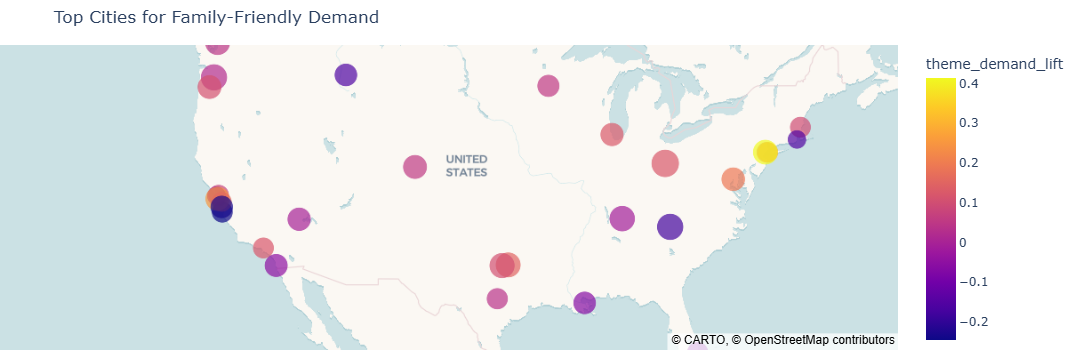

In [73]:
plot_theme_city_map(family_city_summary, 'Family-Friendly')

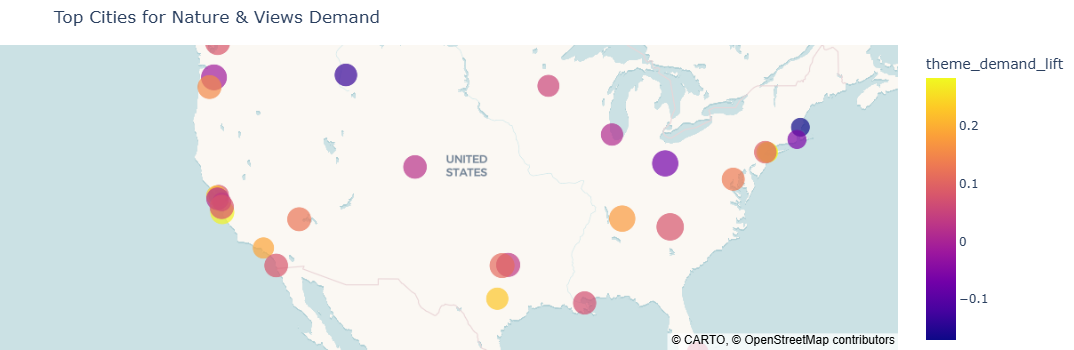

In [74]:
plot_theme_city_map(nature_city_summary, 'Nature & Views')

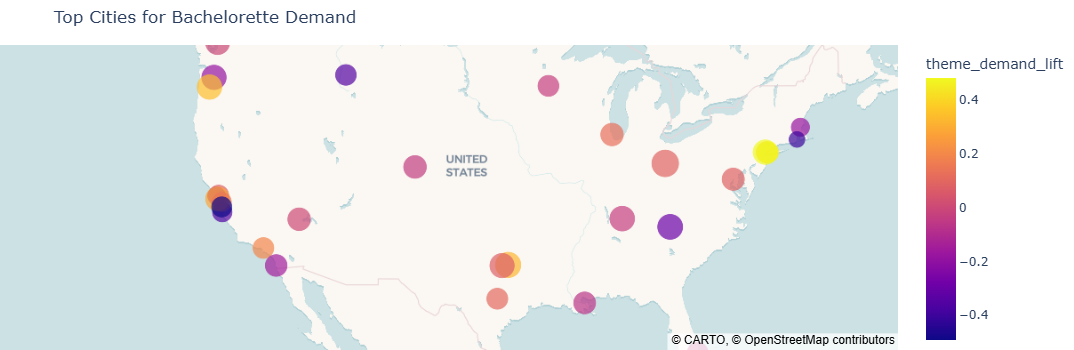

In [75]:
plot_theme_city_map(bachelorette_city_summary, 'Bachelorette')

These are obviously imperfect maps because they don't take in any detail about the location, activities, etc. But it's just to get an idea of what cities support which types of listings. 

## Notebook Summary

In this notebook, I created a location-based Airbnb recommendation workflow.

<b>Goal: </b> enter a latitude, longitude, and radius, then return the top-performing listing types nearby. The final output combines local comp performance with model predictions from the tuned Random Forest model.

   - The local comp analysis shows what's performing well in a given market. The model prediction adds an estimated demand score using predicted reviews per month.

   - The final recommendation table has listing type, bedroom count, pricing, demand metrics, standard amenities, ADR-supporting amenities (higher pricing), possible niche amenities, and predicted reviews per month.

   - The tool works best when the dataset has enough local listings near the target location (the original dataset only contained 31 markets). If the comp count is low, the recommendation is less reliable because there is not enough market data.

The next version of this tool could include a cleaner user input form, Zillow or Redfin property inputs, and better amenity extraction from listing descriptions or property features. It would also be helpful to have actual booking data, actual reviews, age of listing, and a more complete set of Airbnb data for every market. 

In [77]:
# checking that the saved model and feature list load correctly
rf_model = joblib.load('../models/rf_location_recommendation_model.pkl')
rf_features = joblib.load('../models/rf_location_recommendation_features.pkl')

print('Model loaded successfully')
print('Feature count:', len(rf_features))
print(rf_features)

Model loaded successfully
Feature count: 14
['price_clean', 'pricing_competitiveness_score', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'latitude', 'longitude', 'host_is_superhost', 'host_response_time_ord', 'instant_bookable', 'family_friendly_score', 'work_friendly_score', 'amenity_strength_score']


In [78]:
# saving final cleaned datasets used for the project
df.to_csv('../data/processed/airbnb_product_modeling.csv', index=False)

print('Saved final product modeling dataset')

Saved final product modeling dataset
